# 02-4. 피크 위험 확률 모델 비교 — 시간 최대 모델

평가 항목 2(제조 이상 확률 모델 개발·비교)의 핵심 비교입니다. 02-2·02-3의 15분 모델과 **같은 데이터·같은 피크 기준·같은 평가 방식**에서, 시간 최대를 직접 예측하는 모델과 피크 위험 확률 모델(분류기·분위수 확률·스태킹)을 비교합니다.

| 항목 | 기준(15분 분석과 같음) | 이유 |
|---|---|---|
| 데이터 | 2021-07-01 이후만 | 1~6월은 다른 날과 하루치 값이 똑같은 복사 기록이 87%(01-1) |
| 이상 기록 | 7/13·7/15 전력 결측, 0값(계측 중단) 결측, 7/28·7/30은 정답 제외 | 7/13·7/15는 행 순서가 시각 순서가 아님(01-1) |
| 피크 기준 | 1단계 188.7kW(학습 기간 최대 222kW × 0.85), 준비선 178.7kW | 요금(기본요금) 기준에 근거(02-3) |
| 평가 | 8/9~9/14를 1주씩 5번, 매주 그 이전 자료만으로 학습 | 시간 순서 평가(01-2) |
| 경보 평가 | 문턱·확률 보정은 앞 주로 정하고 2~5주차에서 평가 | 02-3도 1주차로 여유값을 정하고 2~5주차로 평가 |
| 비교 단위 | **시간**: 정시에 발행해 그 시간을 예측(시간 최대 = 15분 4칸 중 최댓값) | 15분 모델의 1시간 앞 예측(정시 발행, 4칸)과 정보 시점이 같음 |

시간 최대 모델의 설정은 부록 파이프라인(`appendix/hourly_max_pipeline`)에서 정한 값(STEP 3 튜닝값, STEP 6 분류기 설정)을 그대로 가져오고, 여기서 다시 튜닝하지 않았습니다.

> **주의**: 15분 모델과 시간 최대 모델 모두 9월까지의 결과를 본 뒤 설정이 정해졌기 때문에, 이 비교는 '같은 조건에서의 비교'이며 한 번도 보지 않은 테스트가 아닙니다.

공통 함수(`hourly_utils.py`)와 01-2·02-2가 만든 15분 데이터·최종 예측을 불러옵니다. 시간 단위 표·피처 함수(`power_utils`)는 부록 파이프라인에서 가져옵니다.

In [1]:
# [코드 H-01] 준비: 공통 함수, 15분 데이터·예측 불러오기
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import hourly_utils as mu

font = mu.pu.set_korean_font()
pd.set_option('display.max_columns', 30)
F = mu.load_friend()
print(f"15분 데이터 {len(F['slots']):,}칸({F['slots']['ts'].min():%m/%d}~{F['slots']['ts'].max():%m/%d}), "
      f"1시간 앞 최종 예측 {len(F['final_hour']):,}칸, 하루 앞 최종 예측 {len(F['final_day']):,}칸")
print(f'피크 1단계 {mu.THETA}kW, 준비선 {mu.READY}kW | 한글 글꼴: {font} | 스레드 {mu.pu.N_THREADS}')

15분 데이터 7,296칸(07/01~09/14), 1시간 앞 최종 예측 3,480칸, 하루 앞 최종 예측 3,552칸
피크 1단계 188.7kW, 준비선 178.7kW | 한글 글꼴: Malgun Gothic | 스레드 4


## 1. 정답 만들기와 비교 단위

15분 4칸이 모두 정답으로 쓸 수 있는 시간만 시간 최대(정답)를 만듭니다. '피크 시간'은 4칸 중 하나라도 188.7kW 이상인 시간입니다. 주별 피크 시간 수를 보면 평가할 사건이 얼마나 적은지 알 수 있습니다(신뢰구간이 넓어지는 이유).

In [2]:
# [코드 H-02] 시간 단위 정답과 주별 피크 시간 수 [표 H-00]
truth = mu.hourly_truth(F['slots'], F['days'])
test_hours = truth.index[truth['week'] != '학습']
tbl = truth[truth['valid']].groupby('week').agg(정답_시간=('y', 'size'), 피크_시간=('peak', 'sum'),
                                                최대_kW=('y', 'max')).reindex(['학습'] + list(mu.WEEKS['week']))
display(tbl)
print(f"평가(2~5주차) 피크 시간: {int(tbl.loc[mu.EVAL_WEEKS, '피크_시간'].sum())}개")

,정답_시간,피크_시간,최대_kW
week,,,
학습,840,75,222.0
1주차,168,32,218.0
2주차,168,2,193.0
3주차,149,18,202.0
4주차,168,8,198.0
5주차,215,14,204.0


평가(2~5주차) 피크 시간: 42개


먼저 02-3의 1시간 앞 경보(15분 칸 단위)를 그대로 다시 계산해, 02-3의 결과(재현율 0.77, 정밀도 0.19)와 같은지 확인합니다. 같아야 이후 비교에서 15분 모델의 예측을 올바르게 읽고 있다는 뜻입니다.

In [3]:
# [코드 H-03] 15분 모델 경보(칸 단위) 재현 확인
fh = F['final_hour'].assign(week=lambda d: mu.week_of(d['발행시각']))
e = fh[fh['week'].isin(mu.EVAL_WEEKS) & fh['정답사용'].astype(bool) & fh['전력'].notna()]
lab_c, al_c = e['전력'] >= mu.THETA, e['1시간앞_예측'] >= mu.READY
tp, fp_, fn = int((lab_c & al_c).sum()), int((~lab_c & al_c).sum()), int((lab_c & ~al_c).sum())
print(f'15분 모델 칸 단위(2~5주차): 피크 칸 {int(lab_c.sum())}, 맞힘 {tp}, 헛경보 {fp_}, 놓침 {fn} → '
      f'재현율 {tp / (tp + fn):.2f}, 정밀도 {tp / (tp + fp_):.2f} (02-3 표 t20: 0.77, 0.19)')

15분 모델 칸 단위(2~5주차): 피크 칸 60, 맞힘 46, 헛경보 202, 놓침 14 → 재현율 0.77, 정밀도 0.19 (02-3 표 t20: 0.77, 0.19)


## 2. 시간 최대 모델을 같은 기준으로 학습

시간 단위 표에 같은 데이터 규칙을 적용합니다(7/1 이전·7/13·7/15 전력 결측). 피처는 부록 파이프라인의 S1 피처(달력·과거값·당일 생산계획)에 01-2의 '하루 종류(평일 가동·토요일·휴일)·전날 가동'을 더했습니다. 둘 다 '전날 생산계획을 안다'는 같은 가정에서 쓸 수 있는 정보입니다. 시간 최대가 15분 데이터로 만든 정답과 같은지, 누수 검사를 통과하는지 확인합니다.

In [4]:
# [코드 H-04] 같은 규칙의 시간 단위 표·피처, 누수 검사
m = mu.our_frame(F['days'])
XA, XB = mu.features(m, 'A'), mu.features(m, 'B')
both = truth.index[truth['valid']]
diff = (m.loc[both, 'y'] - truth.loc[both, 'y']).abs().max()
print(f'피처: 트랙 A {XA.shape[1]}개, 트랙 B {XB.shape[1]}개 | 시간 최대 vs 15분 데이터 정답 최대 차이 {diff}')
print(f"7/1 이전 전력 남은 값 {int(m.loc[:'2021-06-30', 'y_obs'].notna().sum())}개, "
      f"7/13·7/15 남은 값 {int(m.loc[m['date'].isin(mu.BROKEN_DAYS), 'y'].notna().sum())}개")
print('동적 누수 검사(예측 시점 이후 값을 바꿔도 피처 불변):',
      mu.pu.check_no_leak(m, 'A', 'S1', n_checks=20), '/', mu.pu.check_no_leak(m, 'B', 'S1', n_checks=20), '통과')

피처: 트랙 A 26개, 트랙 B 24개 | 시간 최대 vs 15분 데이터 정답 최대 차이 0.0
7/1 이전 전력 남은 값 0개, 7/13·7/15 남은 값 0개


동적 누수 검사(예측 시점 이후 값을 바꿔도 피처 불변): 20 / 20 통과


Chronos-2(zero-shot)로 시간 최대를 예측합니다. 트랙 A는 정시마다 직전 시간까지의 계열로 그 시간을, 트랙 B는 매일 00시에 전날까지의 계열과 미래에도 아는 값(시각, 하루 종류)으로 그날 24시간을 예측합니다. 문맥은 7/1 이후만 넣습니다. 처음 실행할 때 계산해 `outputs/preds/`에 저장하고, 다음부터는 저장된 결과를 씁니다(CPU 약 2분).

In [5]:
# [코드 H-05] Chronos-2 시간 최대 예측(저장된 결과가 있으면 사용)
P = mu.OUT / 'preds'
P.mkdir(parents=True, exist_ok=True)
if not (P / 'chronos_A.parquet').exists() or not (P / 'chronos_B.parquet').exists():
    pipe = mu.chronos_pipe()
    mu.chronos_track_a(pipe, m, test_hours).to_parquet(P / 'chronos_A.parquet')
    mu.chronos_track_b(pipe, m, test_hours[test_hours.hour == 0]).to_parquet(P / 'chronos_B.parquet')
ca, cb = pd.read_parquet(P / 'chronos_A.parquet'), pd.read_parquet(P / 'chronos_B.parquet')
print(f'Chronos-2 트랙 A {len(ca)}시간, 트랙 B {len(cb)}시간')

Chronos-2 트랙 A 888시간, 트랙 B 888시간

시험 주마다 그 이전(7/1~) 자료만으로 피크 분류기(부록 STEP 6 설정, 클래스 가중 LightGBM, seed 5개 평균)와 LightGBM 회귀(부록 STEP 3에서 고른 설정)를 학습해 그 주를 예측합니다.

In [6]:
# [코드 H-06] 주별 학습: 피크 분류기·LightGBM 회귀(저장된 결과가 있으면 사용)
if not (P / 'oof_A.parquet').exists() or not (P / 'oof_B.parquet').exists():
    mu.weekly_oof(XA, truth, 'A', mu.pu.SEEDS).to_parquet(P / 'oof_A.parquet')
    mu.weekly_oof(XB, truth, 'B', mu.pu.SEEDS).to_parquet(P / 'oof_B.parquet')
oa, ob = pd.read_parquet(P / 'oof_A.parquet'), pd.read_parquet(P / 'oof_B.parquet')
fp_a = mu.friend_hour_max(F['final_hour'], '1시간앞_예측')
fd = F['final_day'].assign(h=F['final_day']['ts'].dt.floor('h'))
fp_b = mu.friend_hour_max(fd, '하루앞_예측', key='h')
print(f'주별 예측: 트랙 A {len(oa)}시간, 트랙 B {len(ob)}시간 | 15분 모델 시간 최대 예측: 1시간 앞 {fp_a.notna().sum()}, 하루 앞 {fp_b.notna().sum()}')

주별 예측: 트랙 A 888시간, 트랙 B 888시간 | 15분 모델 시간 최대 예측: 1시간 앞 870, 하루 앞 888


## 3. 핵심 비교 ① — 1시간 앞 피크 경보 (2~5주차, 시간 단위)

| 방법 | 내용 |
|---|---|
| 15분 모델: 점예측 ≥ 178.7 | 15분 모델 최종 예측(4칸 중 최대)이 준비선 이상이면 경보(02-3에서 1주차로 정한 여유값 10kW) |
| 달력 규칙 | 평일 가동일 08~12시·13~16시 전부 경보(02-3의 비교 기준) |
| 시간 최대: 분류기 | 피크 분류기 확률 → isotonic 보정 → F1 최대 문턱(앞 주로 맞춤) |
| 시간 최대: Chronos-2 분위수 확률 | Chronos-2 분위수로 P(시간 최대 ≥ 188.7) → 보정 → 문턱 |
| 15분 모델 점예측 + 확률 보정 | 15분 모델 점예측을 isotonic으로 확률로 바꾸고 F1 최대 문턱(문턱 정하기만 시간 최대 방식 적용) |
| 시간 최대: 스태킹 | 분류기·Chronos-2 확률·15분 모델 점예측을 로지스틱으로 결합 → 보정 → 문턱 |
| 시간 최대 Chronos-2 ≥ 178.7 | 15분 모델과 **같은 여유값 규칙**을 Chronos-2 시간 최대 예측에 적용(새로 맞춘 값 없음) |

F1·PR-AUC는 높을수록, Brier는 낮을수록 좋습니다. PR-AUC는 문턱과 상관없이 '피크를 위험한 순서로 줄 세우는 능력'이라 방법 간 비교에 가장 공정합니다.

In [7]:
# [코드 H-07] 1시간 앞 경보 비교 [표 H-01]
S = pd.DataFrame({'week': truth.loc[test_hours, 'week']}, index=test_hours)
S['p_clf'] = oa['p_clf']
S['p_chr'] = mu.pu.peak_prob_from_quantiles(ca, mu.THETA)
S['fp'] = fp_a.reindex(test_hours)
S['fp_m'] = (S['fp'] - mu.THETA) / mu.THETA
lab = truth.loc[test_hours, 'peak'].to_numpy()
ok = truth.loc[test_hours, 'valid'].to_numpy() & S['fp'].notna().to_numpy()
R = mu.forward_alarms(S, lab, ok, ['p_clf', 'p_chr', 'fp'], stack_cols=['p_clf', 'p_chr', 'fp_m'])
ev = R.index
okv, labv = ok[np.isin(test_hours, ev)], truth.loc[ev, 'peak'].to_numpy()
ndays = truth.loc[ev][truth.loc[ev, '가동일'].astype(bool)]['date'].nunique()
cal = (truth.loc[ev, '하루종류'].eq('평일가동') & truth.loc[ev, 'hour'].isin([8, 9, 10, 11, 13, 14, 15])).to_numpy()
alarms = {'15분 모델: 점예측 ≥ 178.7': ((S.loc[ev, 'fp'] >= mu.READY).to_numpy(), S.loc[ev, 'fp'].to_numpy(), None),
          '달력 규칙(위험 시간대)': (cal, None, None),
          '시간 최대 Chronos-2 ≥ 178.7': ((ca['median'].reindex(ev) >= mu.READY).to_numpy(),
                                                ca['median'].reindex(ev).to_numpy(), None)}
names = {'p_clf': '시간 최대: 분류기', 'p_chr': '시간 최대: Chronos-2 분위수 확률', 'fp': '15분 모델 점예측 + 확률 보정', '스태킹': '시간 최대: 스태킹'}
for k, nm in names.items():
    alarms[nm] = (R[f'{k}|alarm'].to_numpy(), R[f'{k}|p'].to_numpy(), R[f'{k}|p'].to_numpy())
rows = [{'방법': nm, **mu.cls_row(labv[okv], a[okv], None if s is None else s[okv], None if p is None else p[okv], ndays)}
        for nm, (a, s, p) in alarms.items()]
H01 = pd.DataFrame(rows)
mu.save_table(H01, 'h01_hour_alarm')
display(H01.round(3))

,방법,피크 시간,경보 시간,맞힌 피크,헛경보,놓친 피크,재현율,정밀도,F1,PR-AUC,Brier,가동일 하루 경보 시간
0,15분 모델: 점예측 ≥ 178.7,42,94,35,59,7,0.833,0.372,0.515,0.389,NaN,3.615
1,달력 규칙(위험 시간대),42,154,41,113,1,0.976,0.266,0.418,NaN,NaN,5.923
2,시간 최대 Chronos-2 ≥ 178.7,42,125,41,84,1,0.976,0.328,0.491,0.383,NaN,4.808
3,시간 최대: 분류기,42,135,34,101,8,0.810,0.252,0.384,0.204,0.079,5.192
4,시간 최대: Chronos-2 분위수 확률,42,43,17,26,25,0.405,0.395,0.400,0.346,0.049,1.654
5,15분 모델 점예측 + 확률 보정,42,85,29,56,13,0.690,0.341,0.457,0.316,0.053,3.269
6,시간 최대: 스태킹,42,49,15,34,27,0.357,0.306,0.330,0.328,0.049,1.885


차이가 우연인지 확인합니다. 2~5주차 시간을 **하루 단위로 다시 뽑아**(2000회) 'F1(방법) − F1(15분 모델 규칙)'의 95% 신뢰구간을 구합니다. 구간이 0보다 아래면 15분 모델 규칙이 유의하게 낫고, 0을 포함하면 차이가 우연 범위입니다.

In [8]:
# [코드 H-08] F1 차이(방법 − 15분 모델 규칙)의 부트스트랩 신뢰구간 [표 H-02]
dates = truth.loc[ev, 'date'].to_numpy()[okv]
base = alarms['15분 모델: 점예측 ≥ 178.7'][0][okv]
L = labv[okv]
brow = []
for nm, (a, _, _) in alarms.items():
    if nm.startswith('15분 모델: 점예측'):
        continue
    aa = a[okv]
    lo, hi = mu.boot_diff(dates, lambda i: mu.f1_of(L[i], aa[i]) - mu.f1_of(L[i], base[i]))
    d = mu.f1_of(L, aa) - mu.f1_of(L, base)
    brow.append({'방법': nm, 'F1 차이': d, '95% CI 하한': lo, '95% CI 상한': hi,
                 '판정': '15분 모델 규칙이 더 좋음' if hi < 0 else ('방법이 더 좋음' if lo > 0 else '차이 없음(우연 범위)')})
H02 = pd.DataFrame(brow)
mu.save_table(H02, 'h02_hour_alarm_boot')
display(H02.round(3))

,방법,F1 차이,95% CI 하한,95% CI 상한,판정
0,달력 규칙(위험 시간대),-0.096,-0.156,-0.028,15분 모델 규칙이 더 좋음
1,시간 최대 Chronos-2 ≥ 178.7,-0.024,-0.081,0.039,차이 없음(우연 범위)
2,시간 최대: 분류기,-0.131,-0.179,-0.068,15분 모델 규칙이 더 좋음
3,시간 최대: Chronos-2 분위수 확률,-0.115,-0.229,0.000,차이 없음(우연 범위)
4,15분 모델 점예측 + 확률 보정,-0.058,-0.139,0.003,차이 없음(우연 범위)
5,시간 최대: 스태킹,-0.185,-0.301,-0.042,15분 모델 규칙이 더 좋음


정밀도-재현율 곡선으로 문턱을 바꿔 가며 비교합니다. 곡선이 위·오른쪽에 있을수록 같은 재현율에서 헛경보가 적다는 뜻입니다. 점은 각 방법이 실제로 쓴 문턱입니다.

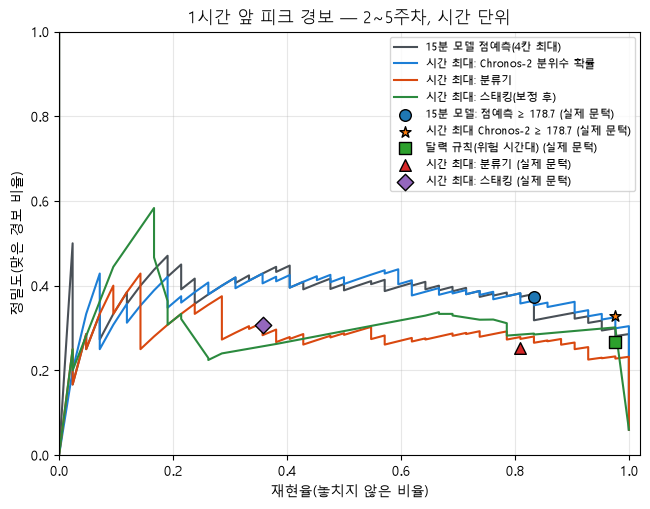

In [9]:
# [코드 H-09] 정밀도-재현율 곡선 [그림 H-01]
from sklearn.metrics import precision_recall_curve
fig, ax = plt.subplots(figsize=(7.5, 5.5))
curves = [('15분 모델 점예측(4칸 최대)', S.loc[ev, 'fp'].to_numpy(), '#495057'),
          ('시간 최대: Chronos-2 분위수 확률', S.loc[ev, 'p_chr'].to_numpy(), '#1c7ed6'),
          ('시간 최대: 분류기', S.loc[ev, 'p_clf'].to_numpy(), '#d9480f'),
          ('시간 최대: 스태킹(보정 후)', R['스태킹|p'].to_numpy(), '#2b8a3e')]
for nm, s, c in curves:
    pr, rc, _ = precision_recall_curve(labv[okv], np.nan_to_num(s[okv]))
    ax.plot(rc, pr, color=c, label=nm)
for nm, mk in [('15분 모델: 점예측 ≥ 178.7', 'o'), ('시간 최대 Chronos-2 ≥ 178.7', '*'), ('달력 규칙(위험 시간대)', 's'),
               ('시간 최대: 분류기', '^'), ('시간 최대: 스태킹', 'D')]:
    r = H01.set_index('방법').loc[nm]
    ax.scatter(r['재현율'], r['정밀도'], marker=mk, s=70, edgecolor='black', zorder=3, label=f'{nm} (실제 문턱)')
ax.set_xlabel('재현율(놓치지 않은 비율)'); ax.set_ylabel('정밀도(맞은 경보 비율)')
ax.set_title('1시간 앞 피크 경보 — 2~5주차, 시간 단위'); ax.set_xlim(0, 1.02); ax.set_ylim(0, 1)
ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.3)
mu.save_fig(fig, 'h01_pr_curve'); plt.show()

## 4. 핵심 비교 ② — 하루 앞 피크 경보 (보조)

02-3의 하루 앞 확률 경보는 노트북 안에서만 계산되어 저장되지 않으므로, 15분 모델은 **하루 앞 최종 예측(기준 곡선, 4칸 최대) + 여유값 규칙**으로 비교합니다. 여유값은 02-3의 1시간 앞 방식대로 1주차에서 재현율 0.9 이상이 되는 가장 작은 값으로 정했습니다. 02-3의 칸 단위 결과(t19)는 단위가 달라 참고로만 봅니다.

In [10]:
# [코드 H-10] 하루 앞 경보 비교 [표 H-03]
SB = pd.DataFrame({'week': truth.loc[test_hours, 'week']}, index=test_hours)
SB['p_clf'], SB['p_chr'] = ob['p_clf'], mu.pu.peak_prob_from_quantiles(cb.reindex(test_hours), mu.THETA)
SB['fp'] = fp_b.reindex(test_hours)
SB['fp_m'] = (SB['fp'] - mu.THETA) / mu.THETA
okb = truth.loc[test_hours, 'valid'].to_numpy() & SB['fp'].notna().to_numpy()
w1 = (SB['week'] == '1주차').to_numpy() & okb
margin = next(mg for mg in range(0, 41) if mu.cls_row(lab[w1], (SB['fp'].to_numpy()[w1] >= mu.THETA - mg))['재현율'] >= 0.9)
RB = mu.forward_alarms(SB, lab, okb, ['p_clf', 'p_chr', 'fp'], stack_cols=['p_clf', 'p_chr', 'fp_m'])
okbv = okb[np.isin(test_hours, RB.index)]
fpv = SB.loc[RB.index, 'fp'].to_numpy()
alarms_b = {f'15분 모델 하루 앞 예측 ≥ {mu.THETA - margin:.1f}(1주차로 정한 여유값 {margin})': (fpv >= mu.THETA - margin, fpv, None),
            '15분 모델 하루 앞 예측 ≥ 188.7(여유값 0)': (fpv >= mu.THETA, fpv, None)}
for k, nm in names.items():
    alarms_b[nm] = (RB[f'{k}|alarm'].to_numpy(), RB[f'{k}|p'].to_numpy(), RB[f'{k}|p'].to_numpy())
H03 = pd.DataFrame([{'방법': nm, **mu.cls_row(labv[okbv], a[okbv], None if s is None else s[okbv],
                                             None if p is None else p[okbv], ndays)} for nm, (a, s, p) in alarms_b.items()])
mu.save_table(H03, 'h03_day_alarm')
display(H03.round(3))

,방법,피크 시간,경보 시간,맞힌 피크,헛경보,놓친 피크,재현율,정밀도,F1,PR-AUC,Brier,가동일 하루 경보 시간
0,15분 모델 하루 앞 예측 ≥ 180.7(1주차로 정한 여유값 8),42,129,34,95,8,0.810,0.264,0.398,0.245,NaN,4.962
1,15분 모델 하루 앞 예측 ≥ 188.7(여유값 0),42,27,7,20,35,0.167,0.259,0.203,0.245,NaN,1.038
2,시간 최대: 분류기,42,174,41,133,1,0.976,0.236,0.380,0.234,0.102,6.692
3,시간 최대: Chronos-2 분위수 확률,42,62,11,51,31,0.262,0.177,0.212,0.183,0.069,2.385
4,15분 모델 점예측 + 확률 보정,42,127,28,99,14,0.667,0.220,0.331,0.202,0.081,4.885
5,시간 최대: 스태킹,42,57,6,51,36,0.143,0.105,0.121,0.134,0.088,2.192


## 5. 핵심 비교 ③ — 점예측(시간 최대 MAE, 1~5주차 전체)

시간 최대를 얼마나 잘 맞히는지 비교합니다. 15분 모델은 15분 값을 예측하도록 만든 것이라 '4칸 예측의 최대'는 실제 시간 최대보다 낮게 나오기 쉽습니다. 즉 이 비교는 시간 최대를 직접 예측하는 모델에 다소 유리합니다(반대로 15분 값 기준이면 15분 모델이 유리). 신뢰구간은 하루 단위 부트스트랩으로 구한 'MAE(방법) − MAE(15분 최종)'입니다.

In [11]:
# [코드 H-11] 시간 최대 점예측 MAE [표 H-04]
v = truth.loc[test_hours]
vv = v['valid'].to_numpy() & fp_a.reindex(test_hours).notna().to_numpy()
yv, dv = v['y'].to_numpy()[vv], v['date'].to_numpy()[vv]
ph = F['pred_hour']
cands = {'1시간 앞': [('15분 최종: 선형 회귀 + Chronos-2', fp_a), ('15분: 선형 회귀', mu.friend_hour_max(ph, '선형 회귀')),
                    ('15분: Chronos-2(+가동 계획)', mu.friend_hour_max(ph, 'Chronos-2 (+가동 계획)')),
                    ('15분: LightGBM', mu.friend_hour_max(ph, 'LightGBM')),
                    ('시간 최대: Chronos-2 zero-shot', ca['median']), ('시간 최대: LightGBM(부록 STEP 3 설정)', oa['lgbm'])],
         '하루 앞': [('15분 최종: 기준 곡선', fp_b), ('시간 최대: Chronos-2 + 공변량', cb['median']),
                   ('시간 최대: LightGBM(부록 STEP 3 설정)', ob['lgbm'])]}
rows, pk = [], v['peak'].to_numpy()[vv]
for horizon, lst in cands.items():
    err0 = np.abs(lst[0][1].reindex(test_hours).to_numpy()[vv] - yv)
    for nm, p in lst:
        err = np.abs(p.reindex(test_hours).to_numpy()[vv] - yv)
        lo, hi = mu.boot_diff(dv, lambda i: err[i].mean() - err0[i].mean())
        plo, phi = mu.boot_diff(dv[pk], lambda i: err[pk][i].mean() - err0[pk][i].mean())
        rows.append({'예측': horizon, '모델': nm, 'MAE': err.mean(), '15분 최종 대비 차이': err.mean() - err0.mean(),
                     '95% CI 하한': lo, '95% CI 상한': hi, '피크 시간 MAE': err[pk].mean(),
                     '피크 시간 차이 CI 하한': plo, '피크 시간 차이 CI 상한': phi})
H04 = pd.DataFrame(rows)
mu.save_table(H04, 'h04_point_mae')
display(H04.round(3))

,예측,모델,MAE,15분 최종 대비 차이,95% CI 하한,95% CI 상한,피크 시간 MAE,피크 시간 차이 CI 하한,피크 시간 차이 CI 상한
0,1시간 앞,15분 최종: 선형 회귀 + Chronos-2,5.853,0.000,0.000,0.000,9.951,0.000,0.000
1,1시간 앞,15분: 선형 회귀,6.039,0.186,-0.022,0.388,9.146,-1.772,0.067
2,1시간 앞,15분: Chronos-2(+가동 계획),6.147,0.294,0.042,0.572,10.939,-0.034,1.984
3,1시간 앞,15분: LightGBM,6.387,0.534,0.281,0.816,10.302,-0.823,1.401
4,1시간 앞,시간 최대: Chronos-2 zero-shot,5.780,-0.073,-0.515,0.405,7.677,-3.362,-1.378
5,1시간 앞,시간 최대: LightGBM(부록 STEP 3 설정),8.183,2.330,1.020,3.823,17.914,0.757,14.316
6,하루 앞,15분 최종: 기준 곡선,7.064,0.000,0.000,0.000,10.028,0.000,0.000
7,하루 앞,시간 최대: Chronos-2 + 공변량,6.891,-0.173,-0.792,0.446,9.379,-2.565,1.558
8,하루 앞,시간 최대: LightGBM(부록 STEP 3 설정),9.816,2.752,1.198,4.452,17.223,0.860,13.498


주별 MAE를 그려, 한 주의 큰 차이 때문에 평균이 달라진 것인지 봅니다.

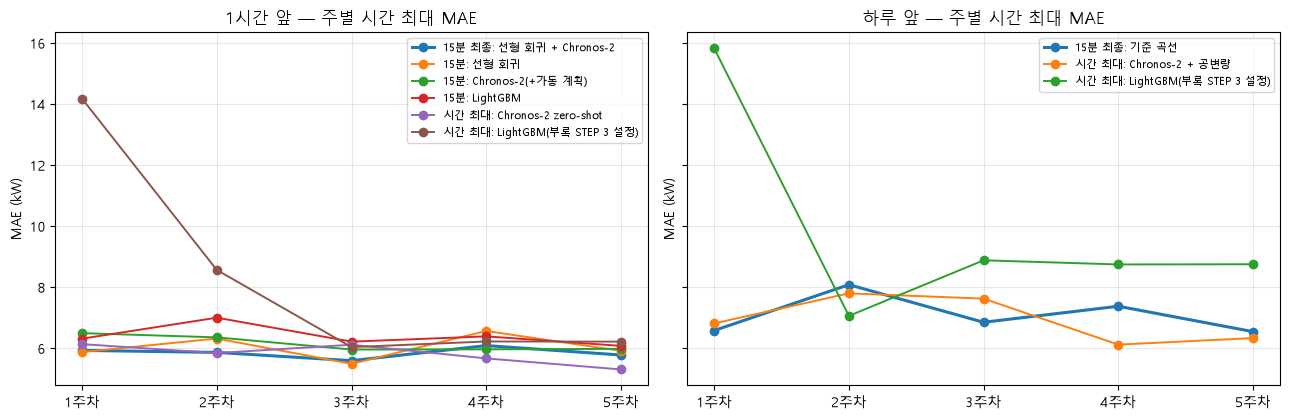

In [12]:
# [코드 H-12] 주별 MAE [그림 H-02]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
wk = v['week'].to_numpy()[vv]
for ax, (horizon, lst) in zip(axes, cands.items()):
    for nm, p in lst:
        err = np.abs(p.reindex(test_hours).to_numpy()[vv] - yv)
        s = pd.Series(err).groupby(wk).mean().reindex(mu.WEEKS['week'])
        ax.plot(s.index, s.values, marker='o', label=nm, lw=2.2 if nm.startswith('15분 최종') else 1.4)
    ax.set_title(f'{horizon} — 주별 시간 최대 MAE'); ax.set_ylabel('MAE (kW)'); ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
mu.save_fig(fig, 'h02_weekly_mae'); plt.show()

아래 셀은 이 노트북의 시간별 예측·확률·경보를 저장합니다. 03-1(영향요인·오류분석)과 06(테스트 예측결과 파일)이 이 파일을 읽습니다.

In [13]:
# [코드 H-12b] 시간별 예측·확률·경보 저장(03-1·06에서 사용)
pts = truth.loc[test_hours, ['y', 'peak', 'valid', 'week', 'date', 'hour', '하루종류', '전날가동', '가동일']].copy()
for horizon, lst in cands.items():
    for nm, p in lst:
        pts[f'{horizon}|{nm}'] = p.reindex(test_hours).to_numpy()
pts.to_parquet(P / 'h_point_preds.parquet')
al_a = pd.DataFrame({nm: a for nm, (a, _, _) in alarms.items()}, index=ev).assign(peak=labv, ok=okv)
al_b = pd.DataFrame({nm: a for nm, (a, _, _) in alarms_b.items()}, index=RB.index).assign(peak=labv, ok=okbv)
al_a.to_parquet(P / 'h_alarms_A.parquet'); al_b.to_parquet(P / 'h_alarms_B.parquet')
R.to_parquet(P / 'h_probs_A.parquet'); RB.to_parquet(P / 'h_probs_B.parquet')
print(f'저장: 점예측 {pts.shape}, 경보 A {al_a.shape}·B {al_b.shape}, 확률 A {R.shape}·B {RB.shape}')

저장: 점예측 (888, 18), 경보 A (720, 9)·B (720, 8), 확률 A (720, 12)·B (720, 12)


## 6. (참고) 부록 파이프라인을 같은 기준으로 채점하면

부록 파이프라인(1~8월 전체로 학습, 테스트 전에 정한 규칙으로 고른 트랙 A Chronos-2 zero-shot + 스태킹 경보)의 9/1~9/14 테스트 예측을, 이 노트북의 정답과 188.7kW 기준으로 다시 채점합니다. 같은 시간의 15분 모델 결과와 나란히 봅니다. 부록의 경보 문턱은 부록의 피크 기준(학습 상위 5%, 187kW)으로 정한 것이라 참고용입니다.

In [14]:
# [코드 H-13] 부록 파이프라인(1~8월 학습)의 테스트 예측 재채점(9/1~9/14) [표 H-05]
import json
K = mu.KIT / 'outputs'
al = pd.read_parquet(K / 'preds' / 'test_alarm_A.parquet')
thr = json.load(open(K / 'tables' / 'test_alarm_thresholds_A.json'))['stack']
z = pd.read_parquet(K / 'preds' / 'oof_test_chronos2_zs_A_S0.parquet').groupby('timestamp')['y_pred'].mean()
z.index = pd.DatetimeIndex(z.index)
h9 = truth.index[(truth.index >= '2021-09-01') & truth['valid'] & fp_a.reindex(truth.index).notna()]
l9, y9 = truth.loc[h9, 'peak'].to_numpy(), truth.loc[h9, 'y'].to_numpy()
n9 = truth.loc[h9][truth.loc[h9, '가동일'].astype(bool)]['date'].nunique()
H05 = pd.DataFrame([
    {'방법': '15분 모델: 점예측 ≥ 178.7', **mu.cls_row(l9, fp_a.reindex(h9).to_numpy() >= mu.READY, n_days=n9),
     'MAE(시간 최대)': np.abs(fp_a.reindex(h9).to_numpy() - y9).mean()},
    {'방법': '부록 파이프라인: 스태킹 경보 / Chronos-2(1~8월 문맥)', **mu.cls_row(l9, al['p_stack'].reindex(h9).to_numpy() >= thr, n_days=n9),
     'MAE(시간 최대)': np.abs(z.reindex(h9).to_numpy() - y9).mean()},
    {'방법': '이 노트북: 분류기 / Chronos-2(7/1~ 문맥)', **mu.cls_row(l9, R['p_clf|alarm'].reindex(h9).to_numpy().astype(bool), n_days=n9),
     'MAE(시간 최대)': np.abs(ca['median'].reindex(h9).to_numpy() - y9).mean()}])
mu.save_table(H05, 'h05_appendix_rescored')
display(H05.round(3))

,방법,피크 시간,경보 시간,맞힌 피크,헛경보,놓친 피크,재현율,정밀도,F1,PR-AUC,Brier,가동일 하루 경보 시간,MAE(시간 최대)
0,15분 모델: 점예측 ≥ 178.7,22,39,16,23,6,0.727,0.410,0.525,NaN,NaN,3.250,5.749
1,부록 파이프라인: 스태킹 경보 / Chronos-2(1~8월 문맥),22,39,14,25,8,0.636,0.359,0.459,NaN,NaN,3.250,5.201
2,이 노트북: 분류기 / Chronos-2(7/1~ 문맥),22,52,17,35,5,0.773,0.327,0.459,NaN,NaN,4.333,5.347


## 7. 결론

아래 코드는 위 표의 값을 그대로 인용해 결론 문장을 출력합니다.

In [15]:
# [코드 H-14] 결론 문장
a = H01.set_index('방법')
f = a.loc['15분 모델: 점예측 ≥ 178.7']
best = a.drop(index=['15분 모델: 점예측 ≥ 178.7', '달력 규칙(위험 시간대)'])['PR-AUC'].idxmax()
print(f"① 1시간 앞 경보(2~5주차, 피크 {int(f['피크 시간'])}시간): 15분 모델 규칙 F1 {f['F1']:.3f}·PR-AUC {f['PR-AUC']:.3f}, "
      f"시간 최대 방법 중 PR-AUC 최고는 '{best}' {a.loc[best, 'PR-AUC']:.3f}(F1 {a.loc[best, 'F1']:.3f})")
for r in H02.itertuples():
    print(f"   {r.방법}: F1 차이 {r._2:+.3f}, 95% CI [{r._3:+.3f}, {r._4:+.3f}] → {r.판정}")
b = H03.set_index('방법')
print(f"② 하루 앞 경보: 가장 높은 F1은 '{b['F1'].idxmax()}' {b['F1'].max():.3f}, PR-AUC 최고는 '{b['PR-AUC'].idxmax()}' {b['PR-AUC'].max():.3f}")
for horizon, g in H04.groupby('예측', sort=False):
    g = g.set_index('모델')
    top = g['MAE'].idxmin()
    print(f"③ {horizon} 시간 최대 MAE: 15분 최종 {g.iloc[0]['MAE']:.2f}kW, 최저 '{top}' {g.loc[top, 'MAE']:.2f}kW "
          f"(차이 95% CI [{g.loc[top, '95% CI 하한']:+.2f}, {g.loc[top, '95% CI 상한']:+.2f}]); "
          f"피크 시간 MAE {g.iloc[0]['피크 시간 MAE']:.2f} → {g.loc[top, '피크 시간 MAE']:.2f}kW "
          f"(CI [{g.loc[top, '피크 시간 차이 CI 하한']:+.2f}, {g.loc[top, '피크 시간 차이 CI 상한']:+.2f}])")

① 1시간 앞 경보(2~5주차, 피크 42시간): 15분 모델 규칙 F1 0.515·PR-AUC 0.389, 시간 최대 방법 중 PR-AUC 최고는 '시간 최대 Chronos-2 ≥ 178.7' 0.383(F1 0.491)
   달력 규칙(위험 시간대): F1 차이 -0.096, 95% CI [-0.156, -0.028] → 15분 모델 규칙이 더 좋음
   시간 최대 Chronos-2 ≥ 178.7: F1 차이 -0.024, 95% CI [-0.081, +0.039] → 차이 없음(우연 범위)
   시간 최대: 분류기: F1 차이 -0.131, 95% CI [-0.179, -0.068] → 15분 모델 규칙이 더 좋음
   시간 최대: Chronos-2 분위수 확률: F1 차이 -0.115, 95% CI [-0.229, +0.000] → 차이 없음(우연 범위)
   15분 모델 점예측 + 확률 보정: F1 차이 -0.058, 95% CI [-0.139, +0.003] → 차이 없음(우연 범위)
   시간 최대: 스태킹: F1 차이 -0.185, 95% CI [-0.301, -0.042] → 15분 모델 규칙이 더 좋음
② 하루 앞 경보: 가장 높은 F1은 '15분 모델 하루 앞 예측 ≥ 180.7(1주차로 정한 여유값 8)' 0.398, PR-AUC 최고는 '15분 모델 하루 앞 예측 ≥ 180.7(1주차로 정한 여유값 8)' 0.245
③ 1시간 앞 시간 최대 MAE: 15분 최종 5.85kW, 최저 '시간 최대: Chronos-2 zero-shot' 5.78kW (차이 95% CI [-0.51, +0.40]); 피크 시간 MAE 9.95 → 7.68kW (CI [-3.36, -1.38])
③ 하루 앞 시간 최대 MAE: 15분 최종 7.06kW, 최저 '시간 최대: Chronos-2 + 공변량' 6.89kW (차이 95% CI [-0.79, +0.45]); 피크 시간 MAE 10.03 → 9.38kW (CI [-2.56, +1.56])
